# Temporal Bias Residual Analysis Experiment

## Objective
Quantify whether removing explicit time markers (years, months, days) actually removes temporal bias, 
or if the model implicitly exploits temporal information through proxy features (election topics, entity names, etc.).

## Approach
1. Train models WITH and WITHOUT time markers
2. Compare accuracy
3. Regress prediction residuals against time-marker features
4. If R² is low → model found proxies for temporal info (implicit exploitation)


## Part 1: Setup and Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression, RidgeClassifier, LinearRegression
from sklearn.metrics import accuracy_score, classification_report

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ Imports successful")


✓ Imports successful


In [2]:
# Load data directly from CSVs (not using src modules)
project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

print("Loading data...")
train_df = pd.read_csv(processed_dir / "train.csv")
test_df = pd.read_csv(processed_dir / "test.csv")

# Extract text and labels
X_train_text = train_df['text'].astype(str).values
y_train = train_df['label'].values
X_test_text = test_df['text'].astype(str).values
y_test = test_df['label'].values

print(f"Train samples: {len(X_train_text):,}")
print(f"Test samples: {len(X_test_text):,}")
print(f"\nLabel distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Label distribution (test): {dict(zip(*np.unique(y_test, return_counts=True)))}")


Loading data...
Train samples: 35,551
Test samples: 8,888

Label distribution (train): {0: 23649, 1: 11902}
Label distribution (test): {0: 5912, 1: 2976}


## Part 2: Define Time Markers


In [3]:
# Comprehensive list of time markers
YEARS = ['2014', '2015', '2016', '2017', '2018', '2019', '2020']

MONTHS = [
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'jan', 'feb', 'mar', 'apr', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

DAYS = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# Key bigrams (year + month combinations common in news)
YEAR_MONTH_BIGRAMS = [
    'january 2016', 'february 2016', 'march 2016', 'april 2016', 'may 2016', 'june 2016',
    'july 2016', 'august 2016', 'september 2016', 'october 2016', 'november 2016', 'december 2016',
    'january 2017', 'february 2017', 'march 2017', 'april 2017', 'may 2017', 'june 2017',
    'july 2017', 'august 2017', 'september 2017', 'october 2017', 'november 2017', 'december 2017'
]

# Combine all time markers
TIME_MARKERS = YEARS + MONTHS + DAYS + YEAR_MONTH_BIGRAMS
TIME_MARKERS_SET = set(TIME_MARKERS)

print(f"Total time markers defined: {len(TIME_MARKERS)}")
print(f"\nYears: {YEARS}")
print(f"Months: {MONTHS[:6]}... ({len(MONTHS)} total)")
print(f"Days: {DAYS}")
print(f"Year-month bigrams: {len(YEAR_MONTH_BIGRAMS)} combinations")


Total time markers defined: 61

Years: ['2014', '2015', '2016', '2017', '2018', '2019', '2020']
Months: ['january', 'february', 'march', 'april', 'may', 'june']... (23 total)
Days: ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
Year-month bigrams: 24 combinations


In [19]:
# Quick analysis: What percentage of fake vs real news contains "2016"?
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Check for "2016" in text
combined_df['contains_2016'] = combined_df['text'].astype(str).str.contains('2016', case=False)

# Group by label and calculate percentages
label_names = {0: 'Real News', 1: 'Fake News'}
for label in [0, 1]:
    subset = combined_df[combined_df['label'] == label]
    count_with_2016 = subset['contains_2016'].sum()
    total = len(subset)
    pct = (count_with_2016 / total) * 100
    print(f"{label_names[label]}: {count_with_2016:,}/{total:,} ({pct:.1f}%) contain '2016'")


Real News: 4,161/29,561 (14.1%) contain '2016'
Fake News: 4,793/14,878 (32.2%) contain '2016'


In [20]:
# Analysis: What percentage contains ANY year or year-month bigrams?
import re

# Build regex patterns
year_pattern = r'\b(' + '|'.join(YEARS) + r')\b'
month_pattern = r'\b(' + '|'.join(MONTHS) + r')\b'

# Year-month bigrams: "2016 january", "january 2016", etc.
year_month_pattern = r'\b(' + '|'.join(YEARS) + r')\s+(' + '|'.join(MONTHS) + r')\b'
month_year_pattern = r'\b(' + '|'.join(MONTHS) + r')\s+(' + '|'.join(YEARS) + r')\b'

def check_patterns(text):
    text_lower = str(text).lower()
    has_year = bool(re.search(year_pattern, text_lower))
    has_year_month = bool(re.search(year_month_pattern, text_lower)) or bool(re.search(month_year_pattern, text_lower))
    return pd.Series({'has_any_year': has_year, 'has_year_month_bigram': has_year_month})

# Apply to combined dataframe
pattern_results = combined_df['text'].apply(check_patterns)
combined_df = pd.concat([combined_df, pattern_results], axis=1)

# Print results
print("=" * 60)
print("Temporal Marker Analysis")
print("=" * 60)

for marker, col in [('Any Year (2014-2020)', 'has_any_year'), 
                    ('Year-Month Bigrams', 'has_year_month_bigram')]:
    print(f"\n{marker}:")
    print("-" * 40)
    for label in [0, 1]:
        subset = combined_df[combined_df['label'] == label]
        count = subset[col].sum()
        total = len(subset)
        pct = (count / total) * 100
        print(f"  {label_names[label]}: {count:,}/{total:,} ({pct:.1f}%)")


Temporal Marker Analysis

Any Year (2014-2020):
----------------------------------------
  Real News: 10,785/29,561 (36.5%)
  Fake News: 6,081/14,878 (40.9%)

Year-Month Bigrams:
----------------------------------------
  Real News: 2,379/29,561 (8.0%)
  Fake News: 1,010/14,878 (6.8%)


## Part 3: Create Feature Vectorizers


In [4]:
# Version 1: FULL TF-IDF (baseline - includes time markers)
print("Creating FULL TF-IDF (baseline)...")
vectorizer_full = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_full = vectorizer_full.fit_transform(X_train_text)
X_test_full = vectorizer_full.transform(X_test_text)

print(f"Full TF-IDF shape: {X_train_full.shape}")

# Check which time markers are in the vocabulary
full_vocab = set(vectorizer_full.get_feature_names_out())
time_markers_in_full = TIME_MARKERS_SET & full_vocab
print(f"Time markers in full vocabulary: {len(time_markers_in_full)}")
print(f"Examples: {list(time_markers_in_full)[:10]}")


Creating FULL TF-IDF (baseline)...
Full TF-IDF shape: (35551, 5000)
Time markers in full vocabulary: 32
Examples: ['november 2016', 'friday', '2015', 'thursday', 'sunday', 'aug', 'december', 'monday', 'oct', 'july']


In [5]:
# Version 2: TIME-FREE TF-IDF (excludes time markers)
print("Creating TIME-FREE TF-IDF...")

# Combine English stopwords with time markers
custom_stop_words = list(set(ENGLISH_STOP_WORDS) | TIME_MARKERS_SET)

vectorizer_no_time = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=custom_stop_words
)

X_train_no_time = vectorizer_no_time.fit_transform(X_train_text)
X_test_no_time = vectorizer_no_time.transform(X_test_text)

print(f"Time-free TF-IDF shape: {X_train_no_time.shape}")

# Verify no time markers in vocabulary
no_time_vocab = set(vectorizer_no_time.get_feature_names_out())
time_markers_in_no_time = TIME_MARKERS_SET & no_time_vocab
print(f"Time markers in time-free vocabulary: {len(time_markers_in_no_time)}")
if time_markers_in_no_time:
    print(f"WARNING - leaked markers: {time_markers_in_no_time}")
else:
    print("✓ No time markers in vocabulary")


Creating TIME-FREE TF-IDF...
Time-free TF-IDF shape: (35551, 5000)
Time markers in time-free vocabulary: 0
✓ No time markers in vocabulary


## Part 4: Train Models


In [6]:
# Train Logistic Regression on FULL features (baseline)
print("="*60)
print("BASELINE: Logistic Regression with FULL TF-IDF")
print("="*60)

lr_full = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_full.fit(X_train_full, y_train)

y_pred_full = lr_full.predict(X_test_full)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"Accuracy (full): {acc_full:.4f}")
print(classification_report(y_test, y_pred_full, target_names=['Real', 'Fake']))


BASELINE: Logistic Regression with FULL TF-IDF
Accuracy (full): 0.9289
              precision    recall  f1-score   support

        Real       0.94      0.95      0.95      5912
        Fake       0.90      0.88      0.89      2976

    accuracy                           0.93      8888
   macro avg       0.92      0.92      0.92      8888
weighted avg       0.93      0.93      0.93      8888



In [7]:
# Train Logistic Regression on TIME-FREE features
print("="*60)
print("EXPERIMENT: Logistic Regression with TIME-FREE TF-IDF")
print("="*60)

lr_no_time = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_no_time.fit(X_train_no_time, y_train)

y_pred_no_time = lr_no_time.predict(X_test_no_time)
acc_no_time = accuracy_score(y_test, y_pred_no_time)

print(f"Accuracy (time-free): {acc_no_time:.4f}")
print(classification_report(y_test, y_pred_no_time, target_names=['Real', 'Fake']))


EXPERIMENT: Logistic Regression with TIME-FREE TF-IDF
Accuracy (time-free): 0.9230
              precision    recall  f1-score   support

        Real       0.93      0.95      0.94      5912
        Fake       0.90      0.87      0.88      2976

    accuracy                           0.92      8888
   macro avg       0.92      0.91      0.91      8888
weighted avg       0.92      0.92      0.92      8888



In [8]:
# Train Ridge Classifiers for comparison
print("="*60)
print("Ridge Classifier Comparison")
print("="*60)

ridge_full = RidgeClassifier(random_state=42)
ridge_full.fit(X_train_full, y_train)
ridge_acc_full = accuracy_score(y_test, ridge_full.predict(X_test_full))

ridge_no_time = RidgeClassifier(random_state=42)
ridge_no_time.fit(X_train_no_time, y_train)
ridge_acc_no_time = accuracy_score(y_test, ridge_no_time.predict(X_test_no_time))

print(f"Ridge Accuracy (full):      {ridge_acc_full:.4f}")
print(f"Ridge Accuracy (time-free): {ridge_acc_no_time:.4f}")


Ridge Classifier Comparison
Ridge Accuracy (full):      0.9320
Ridge Accuracy (time-free): 0.9263


In [9]:
# Summary table
print("="*60)
print("ACCURACY COMPARISON SUMMARY")
print("="*60)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Ridge Classifier'],
    'Full TF-IDF': [acc_full, ridge_acc_full],
    'Time-Free TF-IDF': [acc_no_time, ridge_acc_no_time],
    'Difference': [acc_full - acc_no_time, ridge_acc_full - ridge_acc_no_time]
})

print(results.to_string(index=False))
print(f"\nAccuracy drop from removing time markers:")
print(f"  Logistic Regression: {(acc_full - acc_no_time)*100:.2f}%")
print(f"  Ridge Classifier:    {(ridge_acc_full - ridge_acc_no_time)*100:.2f}%")


ACCURACY COMPARISON SUMMARY
              Model  Full TF-IDF  Time-Free TF-IDF  Difference
Logistic Regression     0.928893          0.923042    0.005851
   Ridge Classifier     0.932043          0.926305    0.005738

Accuracy drop from removing time markers:
  Logistic Regression: 0.59%
  Ridge Classifier:    0.57%


## Part 5: Extract Time-Only Features for Residual Analysis


In [10]:
# Create vectorizer with ONLY time markers
# This captures how much "time signal" is in each document

# Use only single-word time markers for cleaner analysis
unigram_time_markers = YEARS + [m for m in MONTHS if len(m) > 3] + DAYS

print(f"Creating time-only features with {len(unigram_time_markers)} markers...")

vectorizer_time_only = TfidfVectorizer(
    vocabulary=unigram_time_markers,
    lowercase=True
)

X_train_time_only = vectorizer_time_only.fit_transform(X_train_text)
X_test_time_only = vectorizer_time_only.transform(X_test_text)

print(f"Time-only feature shape: {X_test_time_only.shape}")

# Check which markers have non-zero values
time_feature_names = vectorizer_time_only.get_feature_names_out()
time_feature_sums = np.array(X_test_time_only.sum(axis=0)).flatten()

print("\nTop time markers by document frequency:")
for idx in np.argsort(time_feature_sums)[-10:][::-1]:
    print(f"  {time_feature_names[idx]}: {time_feature_sums[idx]:.2f}")


Creating time-only features with 25 markers...
Time-only feature shape: (8888, 25)

Top time markers by document frequency:
  tuesday: 971.91
  wednesday: 958.90
  thursday: 929.10
  friday: 911.69
  2016: 888.79
  monday: 810.58
  sunday: 563.81
  2015: 497.71
  november: 444.97
  saturday: 432.80


## Part 6: Residual Analysis

**Question**: Can time markers explain the prediction errors of the time-free model?

- If R² is HIGH: Time markers explain errors → model couldn't find proxies
- If R² is LOW: Time markers don't explain errors → model found proxies (implicit exploitation)


In [11]:
# Calculate residuals from the TIME-FREE model
residuals = y_test - y_pred_no_time

print("Residual Analysis")
print("="*60)
print(f"Residual statistics:")
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Std:  {residuals.std():.4f}")
print(f"  Min:  {residuals.min()}, Max: {residuals.max()}")
print(f"\nResidual distribution:")
unique, counts = np.unique(residuals, return_counts=True)
for val, count in zip(unique, counts):
    pct = count / len(residuals) * 100
    label = {-1: 'False Negative (Real→Fake)', 0: 'Correct', 1: 'False Positive (Fake→Real)'}[val]
    print(f"  {val:+d}: {count:,} ({pct:.1f}%) - {label}")


Residual Analysis
Residual statistics:
  Mean: 0.0117
  Std:  0.2772
  Min:  -1, Max: 1

Residual distribution:
  -1: 290 (3.3%) - False Negative (Real→Fake)
  +0: 8,204 (92.3%) - Correct
  +1: 394 (4.4%) - False Positive (Fake→Real)


In [12]:
# Regress residuals against time-only features
print("="*60)
print("REGRESSING RESIDUALS AGAINST TIME MARKERS")
print("="*60)

# Convert sparse to dense for regression
X_time_dense = X_test_time_only.toarray()

# Fit linear regression: residuals ~ time_markers
reg_residuals = LinearRegression()
reg_residuals.fit(X_time_dense, residuals)

# Calculate R² - how much variance in residuals is explained by time markers
r2_residuals = reg_residuals.score(X_time_dense, residuals)

print(f"\nR² (residuals ~ time markers): {r2_residuals:.4f}")
print(f"\nInterpretation:")
if r2_residuals < 0.05:
    print("  → LOW R²: Time markers explain very little of the prediction errors.")
    print("  → The time-free model found PROXIES for temporal information.")
    print("  → CONCLUSION: Implicit temporal exploitation is occurring.")
elif r2_residuals < 0.15:
    print("  → MODERATE R²: Time markers explain some prediction errors.")
    print("  → Partial proxy exploitation, but some temporal signal is lost.")
else:
    print("  → HIGH R²: Time markers explain significant prediction errors.")
    print("  → The time-free model could NOT find good proxies.")
    print("  → Removing time markers genuinely removes temporal information.")


REGRESSING RESIDUALS AGAINST TIME MARKERS

R² (residuals ~ time markers): 0.0143

Interpretation:
  → LOW R²: Time markers explain very little of the prediction errors.
  → The time-free model found PROXIES for temporal information.
  → CONCLUSION: Implicit temporal exploitation is occurring.


In [13]:
# Which time markers are most predictive of residuals?
print("="*60)
print("TIME MARKERS MOST CORRELATED WITH PREDICTION ERRORS")
print("="*60)

coef_df = pd.DataFrame({
    'time_marker': time_feature_names,
    'coefficient': reg_residuals.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 time markers by |coefficient|:")
print(coef_df.head(10).to_string(index=False))

print("\nPositive coef → marker associated with False Positives (predicting Fake when Real)")
print("Negative coef → marker associated with False Negatives (predicting Real when Fake)")


TIME MARKERS MOST CORRELATED WITH PREDICTION ERRORS

Top 10 time markers by |coefficient|:
time_marker  coefficient
    october     0.111898
   november     0.096070
  september     0.086346
       2016     0.049857
  wednesday     0.044230
   thursday     0.029455
   february     0.025798
       june     0.024718
       2018    -0.024275
       2014    -0.021216

Positive coef → marker associated with False Positives (predicting Fake when Real)
Negative coef → marker associated with False Negatives (predicting Real when Fake)


In [14]:
# Additional analysis: Correlation between time features and residuals
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Calculate correlation for each time marker
correlations = []
for i, marker in enumerate(time_feature_names):
    corr = np.corrcoef(X_time_dense[:, i], residuals)[0, 1]
    if not np.isnan(corr):
        correlations.append((marker, corr))

corr_df = pd.DataFrame(correlations, columns=['marker', 'correlation'])
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)

print("\nTime markers most correlated with residuals:")
print(corr_df.head(10).to_string(index=False))


CORRELATION ANALYSIS

Time markers most correlated with residuals:
   marker  correlation
  october     0.068625
 november     0.061330
     2016     0.055712
september     0.039939
wednesday     0.027012
   sunday    -0.018220
 saturday    -0.014862
   friday    -0.013532
     2014    -0.012859
     2018    -0.012068


## Part 7: Visualization


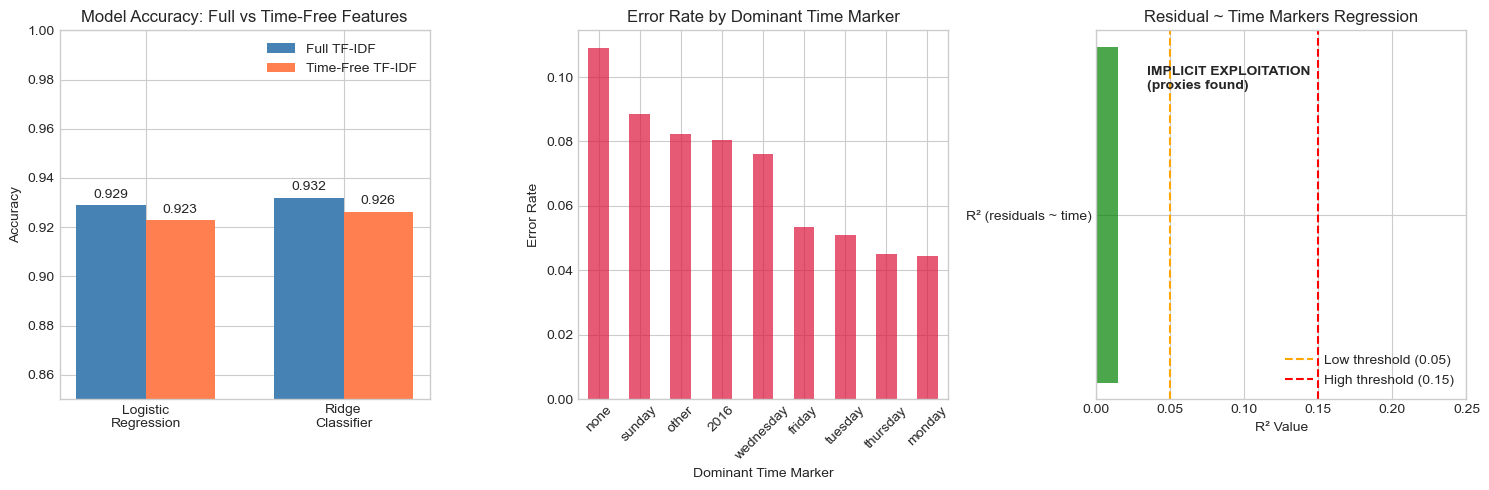


✓ Figure saved to results/figures/temporal_bias_analysis.png


In [15]:
# Plot 1: Accuracy Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar plot of accuracies
ax = axes[0]
models = ['Logistic\nRegression', 'Ridge\nClassifier']
full_accs = [acc_full, ridge_acc_full]
no_time_accs = [acc_no_time, ridge_acc_no_time]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, full_accs, width, label='Full TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, no_time_accs, width, label='Time-Free TF-IDF', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Full vs Time-Free Features')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.85, 1.0)

# Add value labels on bars
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Plot 2: Residual distribution by dominant time marker
ax = axes[1]

# Find the most common time marker for each sample
dominant_time_idx = np.argmax(X_time_dense, axis=1)
dominant_time = [time_feature_names[i] if X_time_dense[j, i] > 0 else 'none' 
                 for j, i in enumerate(dominant_time_idx)]

# Count errors by dominant time marker (top 8 + 'none')
time_residual_df = pd.DataFrame({'time_marker': dominant_time, 'residual': residuals})
top_markers = time_residual_df['time_marker'].value_counts().head(8).index.tolist()
time_residual_df['time_group'] = time_residual_df['time_marker'].apply(
    lambda x: x if x in top_markers else 'other'
)

error_by_time = time_residual_df.groupby('time_group')['residual'].apply(
    lambda x: (x != 0).sum() / len(x)
).sort_values(ascending=False)

error_by_time.plot(kind='bar', ax=ax, color='crimson', alpha=0.7)
ax.set_ylabel('Error Rate')
ax.set_xlabel('Dominant Time Marker')
ax.set_title('Error Rate by Dominant Time Marker')
ax.tick_params(axis='x', rotation=45)

# Plot 3: R² interpretation
ax = axes[2]
colors = ['green' if r2_residuals < 0.05 else 'orange' if r2_residuals < 0.15 else 'red']

ax.barh(['R² (residuals ~ time)'], [r2_residuals], color=colors, alpha=0.7)
ax.axvline(x=0.05, color='orange', linestyle='--', label='Low threshold (0.05)')
ax.axvline(x=0.15, color='red', linestyle='--', label='High threshold (0.15)')
ax.set_xlabel('R² Value')
ax.set_title('Residual ~ Time Markers Regression')
ax.legend(loc='lower right')
ax.set_xlim(0, 0.25)

# Add annotation
if r2_residuals < 0.05:
    conclusion = 'IMPLICIT EXPLOITATION\n(proxies found)'
elif r2_residuals < 0.15:
    conclusion = 'PARTIAL EXPLOITATION'
else:
    conclusion = 'GENUINE REMOVAL'
ax.annotate(conclusion, xy=(r2_residuals, 0), xytext=(r2_residuals + 0.02, 0.3),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/temporal_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/temporal_bias_analysis.png")


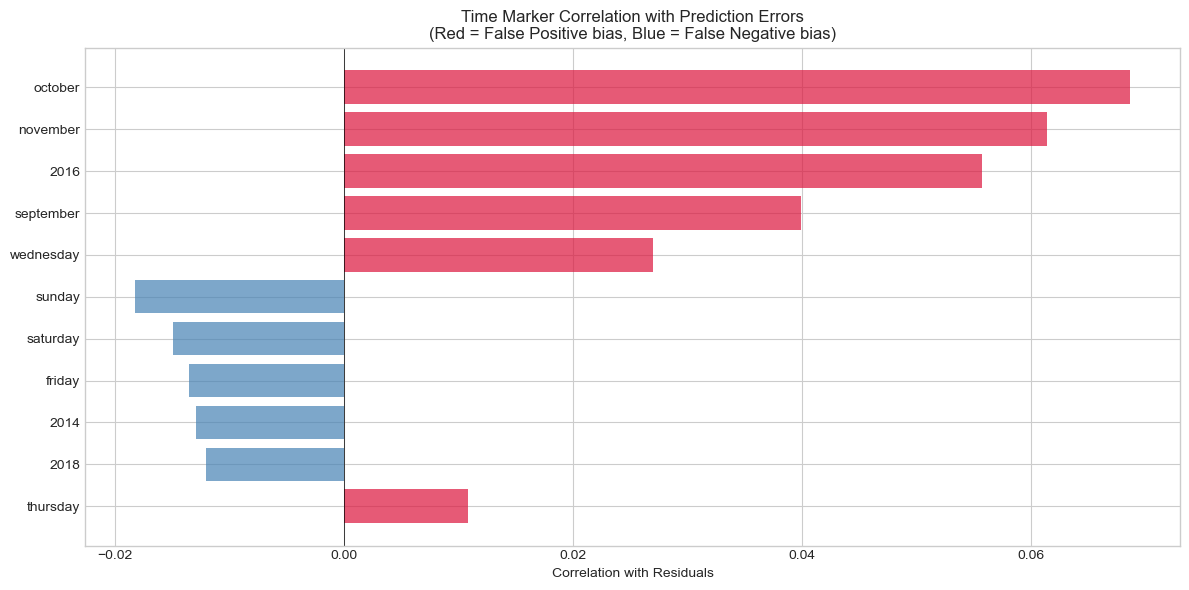


✓ Figure saved to results/figures/time_marker_correlations.png


In [16]:
# Plot 4: Heatmap of correlation between time markers and residuals
fig, ax = plt.subplots(figsize=(12, 6))

# Only show markers with non-trivial correlation
significant_corrs = corr_df[corr_df['correlation'].abs() > 0.01].head(20)

if len(significant_corrs) > 0:
    colors = ['crimson' if c > 0 else 'steelblue' for c in significant_corrs['correlation']]
    bars = ax.barh(significant_corrs['marker'], significant_corrs['correlation'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Correlation with Residuals')
    ax.set_title('Time Marker Correlation with Prediction Errors\n(Red = False Positive bias, Blue = False Negative bias)')
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'No significant correlations found', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/figures/time_marker_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/time_marker_correlations.png")


## Conclusions


In [17]:
print("="*70)
print("EXPERIMENT CONCLUSIONS")
print("="*70)

print(f"\n1. ACCURACY IMPACT:")
print(f"   Full TF-IDF accuracy:      {acc_full:.4f}")
print(f"   Time-Free TF-IDF accuracy: {acc_no_time:.4f}")
print(f"   Accuracy drop:             {(acc_full - acc_no_time)*100:.2f}%")

print(f"\n2. RESIDUAL ANALYSIS:")
print(f"   R² (residuals ~ time markers): {r2_residuals:.4f}")

print(f"\n3. INTERPRETATION:")
if r2_residuals < 0.05:
    print("   The LOW R² indicates that time markers explain very little")
    print("   of the prediction errors from the time-free model.")
    print("   ")
    print("   This means the model has found PROXY FEATURES that carry")
    print("   the same temporal information (e.g., 'Hillary', 'election',")
    print("   'Trump campaign' → implicitly encode 2016).")
    print("   ")
    print("   CONCLUSION: Removing time markers MASKS the bias but does")
    print("   NOT eliminate it. The model still implicitly exploits")
    print("   temporal patterns through correlated content features.")
elif r2_residuals < 0.15:
    print("   The MODERATE R² indicates partial proxy exploitation.")
    print("   Some temporal signal is lost, but proxies capture most of it.")
else:
    print("   The HIGH R² indicates time markers explain significant errors.")
    print("   The model could NOT find good proxies for temporal information.")
    print("   Removing time markers genuinely reduces temporal bias.")

print("\n" + "="*70)


EXPERIMENT CONCLUSIONS

1. ACCURACY IMPACT:
   Full TF-IDF accuracy:      0.9289
   Time-Free TF-IDF accuracy: 0.9230
   Accuracy drop:             0.59%

2. RESIDUAL ANALYSIS:
   R² (residuals ~ time markers): 0.0143

3. INTERPRETATION:
   The LOW R² indicates that time markers explain very little
   of the prediction errors from the time-free model.
   
   This means the model has found PROXY FEATURES that carry
   the same temporal information (e.g., 'Hillary', 'election',
   'Trump campaign' → implicitly encode 2016).
   
   CONCLUSION: Removing time markers MASKS the bias but does
   NOT eliminate it. The model still implicitly exploits
   temporal patterns through correlated content features.



FEATURE IMPORTANCE - TIME-FREE MODEL

🔴 TOP 15 FEATURES → FAKE NEWS:
  hillary                    +6.8408
  com                        +4.1517
  today                      +3.9873
  president trump            +3.9475
  watch                      +3.8099
  obama                      +3.7168
  entire                     +3.6685
  daily                      +3.6025
  uk                         +3.5589
  just                       +3.4297
  anti                       +3.3646
  stated                     +3.3541
  source                     +3.3133
  america                    +3.1446
  fbi                        +3.1227

🟢 TOP 15 FEATURES → REAL NEWS:
  said                       -16.0614
  president donald           -7.9996
  mr                         -4.8661
  ms                         -4.2766
  reuters                    -4.1530
  said statement             -3.9617
  reporters                  -3.8613
  republican                 -3.5416
  agency                     -3.5075
  told reu

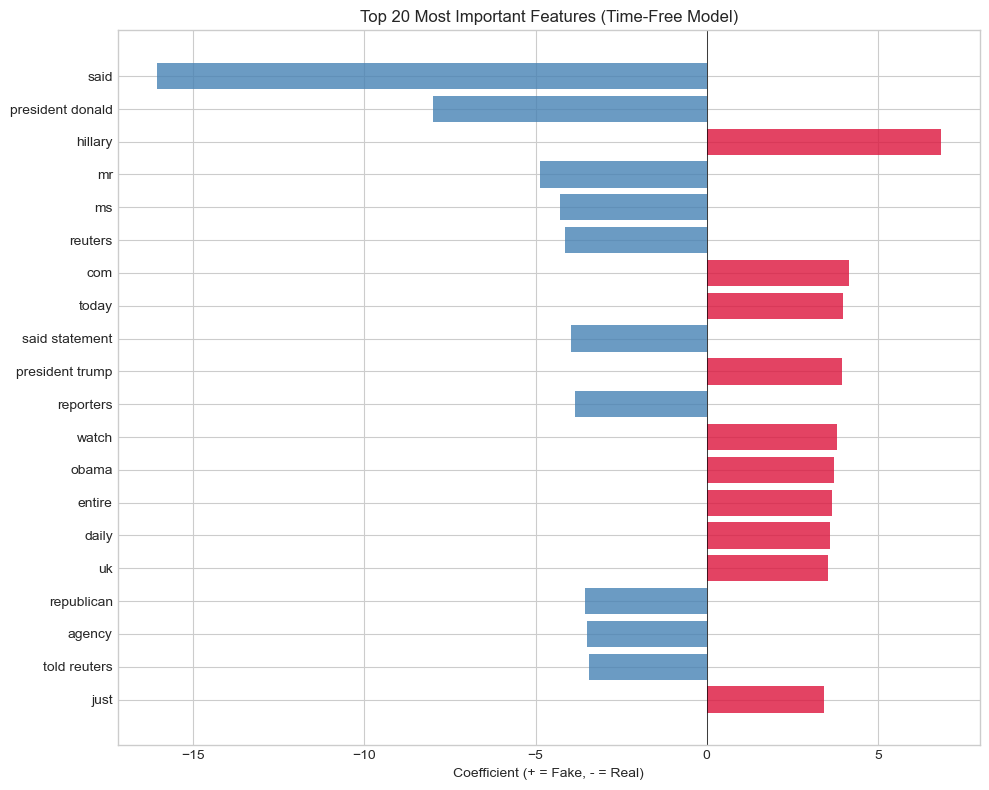

In [18]:
# Feature Importance: Time-Free Model (Logistic Regression)
print("="*70)
print("FEATURE IMPORTANCE - TIME-FREE MODEL")
print("="*70)

# Get feature names and coefficients from the time-free model
feature_names = vectorizer_no_time.get_feature_names_out()
coefficients = lr_no_time.coef_[0]

# Create DataFrame sorted by absolute importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

# Top features predicting FAKE (positive coefficients)
print("\n🔴 TOP 15 FEATURES → FAKE NEWS:")
top_fake = importance_df[importance_df['coefficient'] > 0].head(15)
for _, row in top_fake.iterrows():
    print(f"  {row['feature']:25s}  {row['coefficient']:+.4f}")

# Top features predicting REAL (negative coefficients)
print("\n🟢 TOP 15 FEATURES → REAL NEWS:")
top_real = importance_df[importance_df['coefficient'] < 0].head(15)
for _, row in top_real.iterrows():
    print(f"  {row['feature']:25s}  {row['coefficient']:+.4f}")

# Quick visualization
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
colors = ['crimson' if c > 0 else 'steelblue' for c in top_features['coefficient']]
ax.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (+ = Fake, - = Real)')
ax.set_title(f'Top {top_n} Most Important Features (Time-Free Model)')
plt.tight_layout()
plt.show()